In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')


import pickle
#scikit learn 1.2.2 is used to write this notes

In [2]:
from google.colab import drive

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv('/content/drive/MyDrive/Capstone Projects/Texas_Employee_salary_Prediction/salary.csv')
data

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,...,12.93000,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN


# Basic Checks

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

In [8]:
data.isnull().sum()

,0
AGENCY,0
AGENCY NAME,0
LAST NAME,0
FIRST NAME,0
MI,0
CLASS CODE,0
CLASS TITLE,0
ETHNICITY,0
GENDER,0
STATUS,0


In [9]:
(data.isnull().sum()/len(data))*100

,0
AGENCY,0.000000
AGENCY NAME,0.000000
LAST NAME,0.000000
FIRST NAME,0.000000
MI,0.000000
CLASS CODE,0.000000
CLASS TITLE,0.000000
ETHNICITY,0.000000
GENDER,0.000000
STATUS,0.000000


- duplicated, multiple_full_time_jobs, combined_multiple_jobs, summed_annual_salary, hide_from_search Columns has contain more than 90% Null values. so These columns will be deleted.

In [10]:
# data.drop(['duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs', 'summed_annual_salary', 'hide_from_search'], axis=1, inplace=True)

In [11]:
data.describe()

,AGENCY,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,1.494810e+05,14.0,16.000000
mean,545.736288,0.346488,39.714918,4226.184248,50714.210973,5.651930e+05,1.0,74303.955000
std,139.057691,4.211485,2.323855,2093.111691,25117.340292,4.786212e+05,0.0,51925.944282
min,101.000000,0.000000,1.000000,50.000000,600.000000,1.000000e+00,1.0,18000.000000
25%,529.000000,0.000000,40.000000,3019.840000,36238.080000,1.133340e+05,1.0,32962.500000
50%,530.000000,0.000000,40.000000,3720.170000,44642.040000,3.463730e+05,1.0,48063.300000
75%,696.000000,0.000000,40.000000,4865.810000,58389.720000,1.100500e+06,1.0,123751.770000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,1.0,171383.400000


In [12]:
data.describe(include='O')

,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,duplicated,combined_multiple_jobs,hide_from_search
count,149481,149481,149481,149481,149481,149481,149481,149481,149481,149481,143,97,16
unique,113,38675,23559,27,1481,1422,6,2,11,6295,1,1,1
top,HEALTH AND HUMAN SERVICES COMMISSION ...,SMITH,MICHAEL,,4504,CORREC OFFICER IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/01/17,True,True,True
freq,36667,1243,1843,38408,9267,9267,67142,85328,142502,12359,143,97,16


## EDA Observations

### Numerical Variables

1. The dataset contains 149,481 records.
2. Most employees work approximately 40 hours per week.
3. Annual salary has a median of usd44,642.04 and a maximum of usd553,500, indicating possible outliers and right skewness.
4. Monthly salary also shows a large difference between the median and maximum values.
5. HRLY RATE contains many zero values and requires further investigation.
6. AGENCY and STATE NUMBER appear to represent codes/identifiers rather than continuous numerical variables.
7. multiple_full_time_jobs and summed_annual_salary have extremely high missing-value percentages and require further investigation.

### Categorical Variables

1. There are 113 unique agency names.
2. There are 1,481 unique class codes and 1,422 unique class titles.
3. Gender contains 2 categories and ethnicity contains 6 categories.
4. Status contains 11 employment categories.
5. Employee name columns have high cardinality and may not be useful for predictive modeling.
6. Administrative columns such as duplicated, combined_multiple_jobs, and hide_from_search contain very few valid observations and should be evaluated before modeling.

In [13]:

# !pip install pandas-profiling
# !pip install ydata-profiling

In [14]:
# from ydata_profiling import ProfileReport
# from ydata_profiling import ProfileReport

In [15]:
# profile = ProfileReport(data, title='ExploratoryDataAnalysis', explorative=True)

In [16]:
# import warnings
# warnings.filterwarnings("ignore")

In [17]:
# profile

# EDA


In [18]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])


In [19]:
numeric_data.shape

(149481, 8)

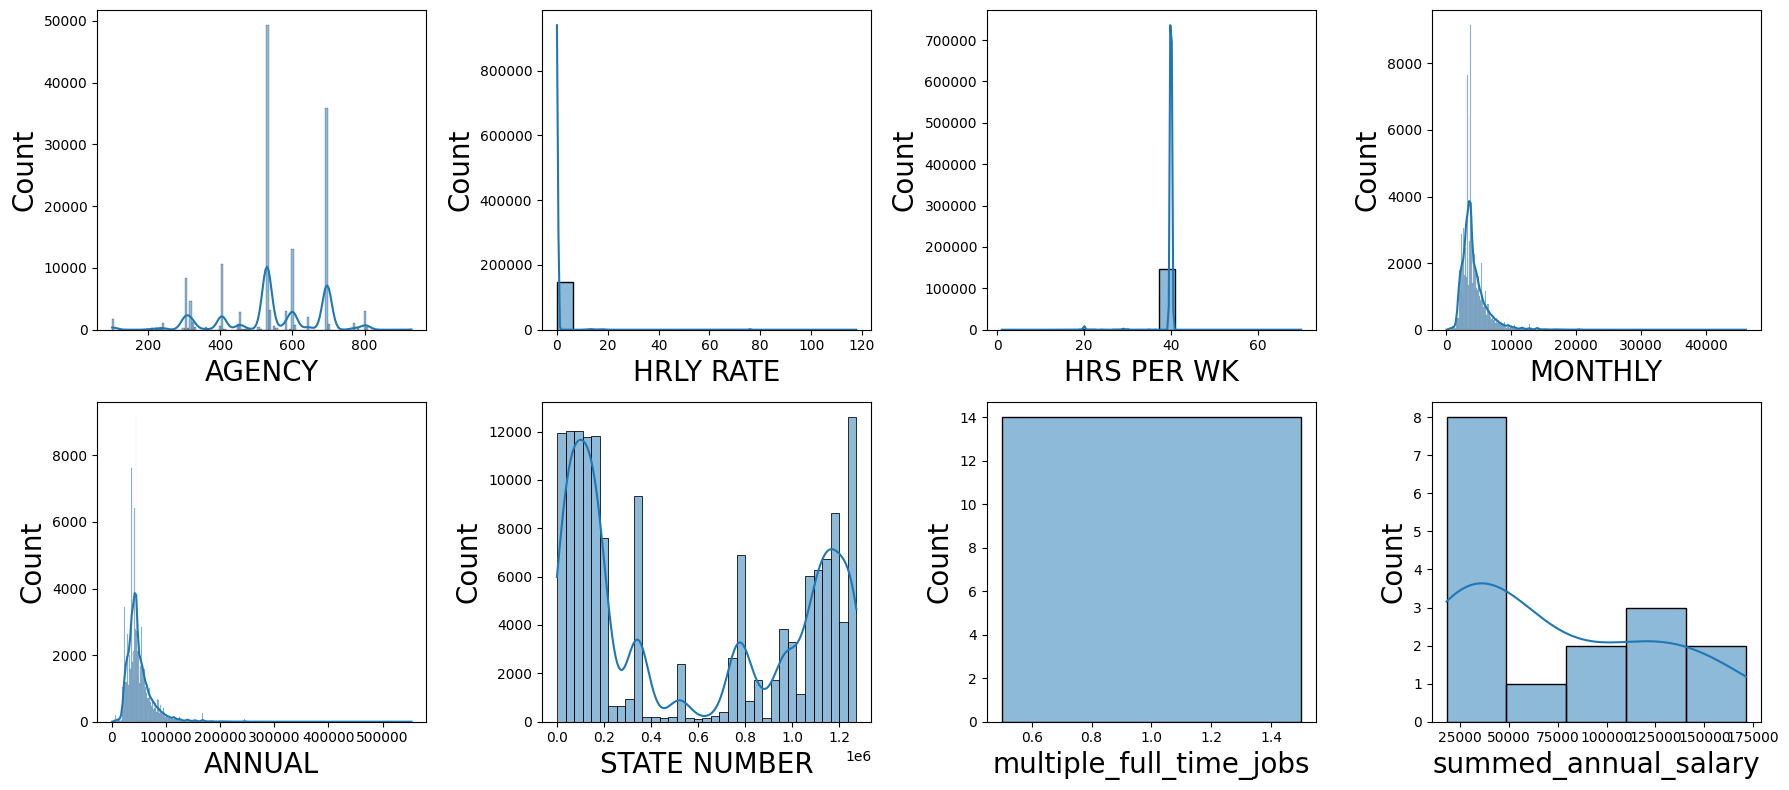

In [20]:
plt.figure(figsize=(18, 8), facecolor='white')
plotnumber = 1
for i in numeric_data.columns:
  if plotnumber <= 8:
    ax = plt.subplot(2,4, plotnumber)
    sns.histplot(data[i], kde=True)
    plt.xlabel(i, fontsize=20)
    plt.ylabel('Count', fontsize=20)
    plotnumber += 1
plt.tight_layout()
plt.show()

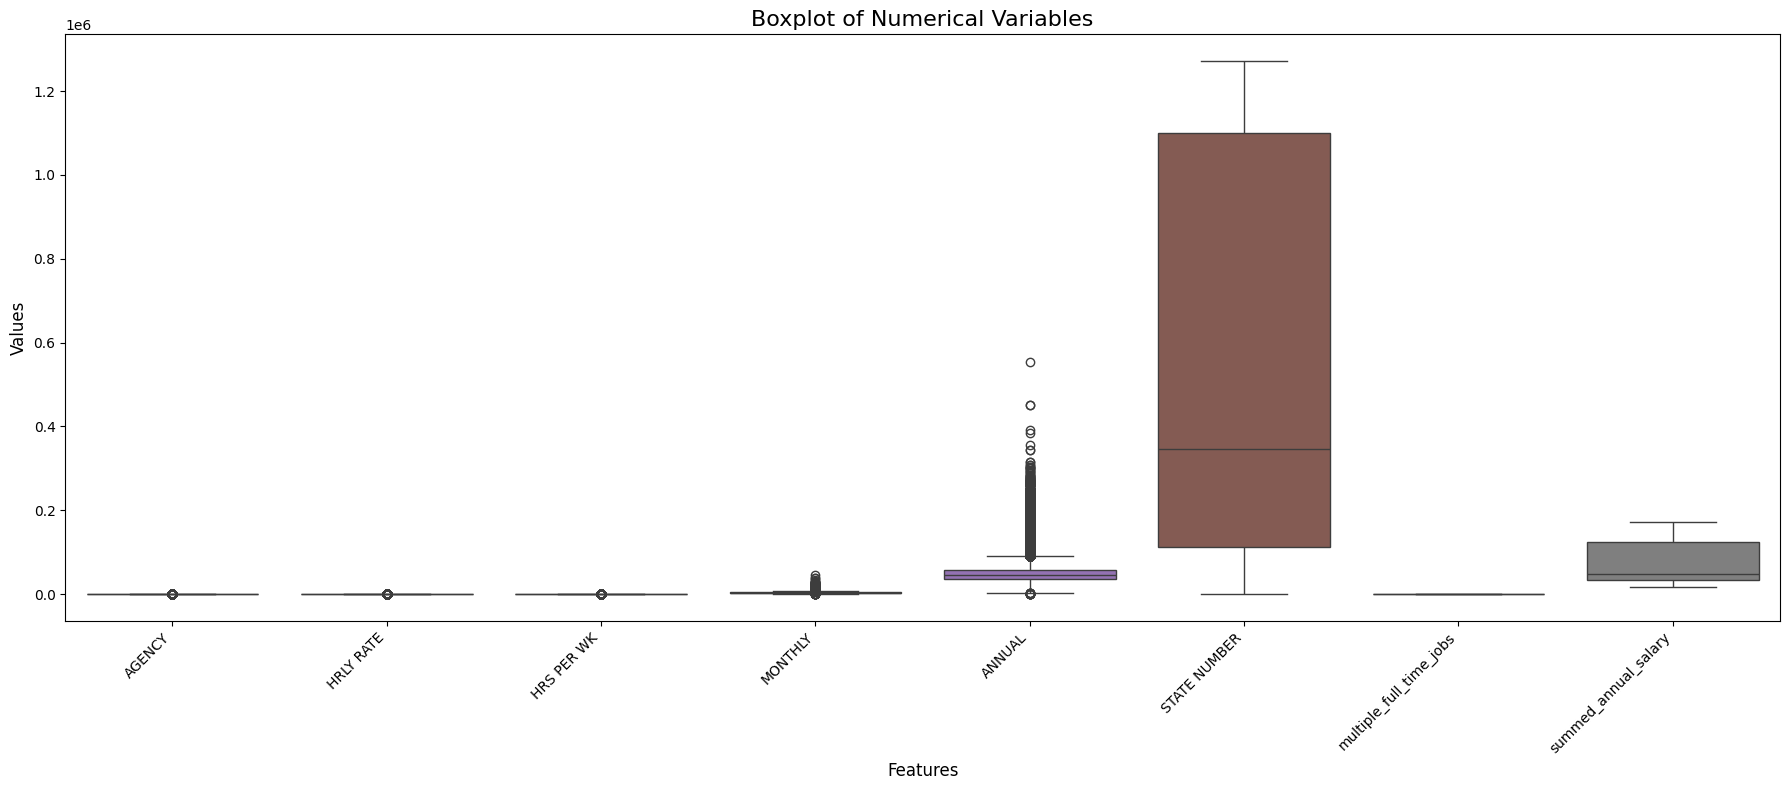

In [21]:
plt.figure(figsize=(18, 8))
sns.boxplot(data[numeric_data.columns])

plt.xticks(rotation=45,ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title('Boxplot of Numerical Variables', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Values', fontsize=12)

plt.tight_layout()
plt.show()

# Who are the outliers in the salaries?

In [22]:

#1. Find the salary outlier boundaries

Q1 = data['ANNUAL'].quantile(0.25)
Q3 = data['ANNUAL'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 36238.08
Q3: 58389.72
IQR: 22151.64
Lower Bound: 3010.6200000000026
Upper Bound: 91617.18


In [23]:
  # Get the actual outlier records
Salary_Outlier = data[data['ANNUAL'] > upper_bound]
Salary_Outlier.shape

(9018, 21)

In [24]:
SalaryOutlieredPerson = Salary_Outlier[['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'CLASS CODE',
       'CLASS TITLE', 'STATUS', 'STATE NUMBER']]

In [25]:
SalaryOutlieredPerson[['FIRST NAME']].value_counts()

,count
FIRST NAME,
MICHAEL,191
JOHN,186
DAVID,182
JAMES,177
ROBERT,146
...,...
ISIDRO,1
ISELA,1
IRMA,1


# What departments/roles have the biggest wage disparities between managers and employees?

In [26]:


data['ANNUAL'].max()

553500.0

In [27]:
manager_titles = data[
    data['CLASS TITLE'].str.contains('MANAGER|DIRECTOR|SUPERVISOR|ADMINISTRATOR|CHIEF', case=False, na = False)
]

manager_titles['CLASS TITLE'].value_counts()

,count
CLASS TITLE,
DIRECTOR II,765
DIRECTOR III,589
MAINTENANCE SUPERVISOR III,588
PROGRAM SUPERVISOR V,537
PROGRAM SUPERVISOR III,435
...,...
SYSTEMS ADMINISTRATOR,1
CHIEF TRADER II,1
DIRECTOR OF INVESTMENTS,1


In [28]:
data['ROLES'] = data['CLASS TITLE'].apply(lambda x: 'Managerial'
if any(word in str(x).upper()
for word in ['MANAGER', 'DIRECTOR', 'SUPERVISOR', 'ADMINISTRATOR', 'CHIEF'])
else 'Employee'
)

In [29]:
data['ROLES'].value_counts()

,count
ROLES,
Employee,141435
Managerial,8046


In [30]:
# Compare manager vs employee salaries
role_salary = data.groupby('ROLES')['ANNUAL'].agg(
    ['count', 'mean', 'median', 'min', 'max']

)
role_salary

,count,mean,median,min,max
ROLES,,,,,
Employee,141435,48651.249733,44642.04,600.0,299812.92
Managerial,8046,86977.562073,77489.58,6000.0,553500.00


In [31]:
Department_salary = data.groupby(['AGENCY NAME', 'ROLES'])['ANNUAL'].agg(['count', 'mean', 'median']).reset_index()

In [32]:
wage_disparity = Department_salary.pivot(
    index = 'AGENCY NAME',
    columns = 'ROLES',
    values = 'mean'
)

In [33]:
wage_disparity['WAGE_GAP'] = (wage_disparity['Managerial']-wage_disparity['Employee'])

In [34]:
wage_disparity.sort_values('WAGE_GAP', ascending=False).head(20)

ROLES,Employee,Managerial,WAGE_GAP
AGENCY NAME,,,
CANCER PREVENTION AND RESEARCH INSTITUTE OF TEXAS,72609.621818,206399.138182,133789.516364
THIRD COURT OF APPEALS DISTRICT,92608.308387,187800.000000,95191.691613
SECOND COURT OF APPEALS DISTRICT,93137.108571,187800.000000,94662.891429
NINTH COURT OF APPEALS DISTRICT,95892.942000,187800.000000,91907.058000
THIRTEENTH COURT OF APPEALS DISTRICT,96848.544828,187800.000000,90951.455172
FIFTH COURT OF APPEALS DISTRICT,97409.764068,187800.000000,90390.235932
OFFICE OF CAPITAL AND FORENSIC WRITS,61571.238000,148509.960000,86938.722000
TWELFTH COURT OF APPEALS DISTRICT,103174.988571,187800.000000,84625.011429
OFFICE OF THE GOVERNOR,70619.127652,153246.083478,82626.955826


# Have salaries and total compensations for some roles/ departments/ head-count changed over time?

In [35]:


# Convert EMPLOY DATE to date
data['EMPLOY DATE'] = pd.to_datetime(data['EMPLOY DATE'], errors='coerce')

data['EMPLOY YEAR'] = data['EMPLOY DATE'].dt.year

In [36]:
data['EMPLOY YEAR'].value_counts().sort_index()

,count
EMPLOY YEAR,
1976,5
1977,7
1978,5
1979,12
1980,10
1981,29
1982,21
1983,41
1984,53


In [37]:
# 2. Analyze salary and headcount over time

yearly_analysis = data.groupby('EMPLOY YEAR').agg(
    HEADCOUNT = ('ANNUAL', 'count'),
    AVG_SALARY = ('ANNUAL', 'mean'),
    MEDIAN_SALARY = ('ANNUAL', 'median'),
    TOTAL_SALARY = ('ANNUAL', 'sum')
).reset_index()

yearly_analysis


,EMPLOY YEAR,HEADCOUNT,AVG_SALARY,MEDIAN_SALARY,TOTAL_SALARY
0,1976,5,87172.608000,91528.92,4.358630e+05
1,1977,7,91151.365714,90300.36,6.380596e+05
2,1978,5,96835.008000,84478.92,4.841750e+05
3,1979,12,93403.790000,85727.10,1.120845e+06
4,1980,10,91393.200000,87521.40,9.139320e+05
5,1981,29,89945.557241,96658.32,2.608421e+06
6,1982,21,103028.702857,94968.00,2.163603e+06
7,1983,41,100688.124878,105000.00,4.128213e+06
8,1984,53,85607.486038,73788.00,4.537197e+06
9,1985,84,84357.985714,74094.00,7.086071e+06


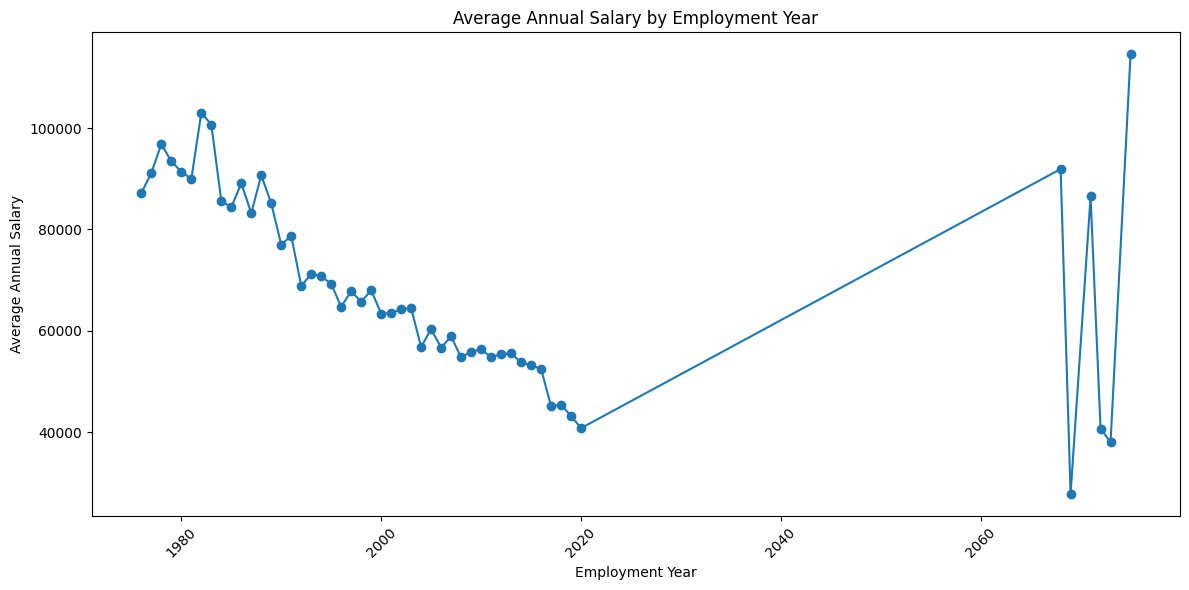

In [38]:
# 3. Plot salary over time

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6), facecolor='white')
plt.plot(
    yearly_analysis['EMPLOY YEAR'],
    yearly_analysis['AVG_SALARY'],
    marker='o',
    )

plt.title('Average Annual Salary by Employment Year')
plt.xlabel('Employment Year')
plt.ylabel('Average Annual Salary')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

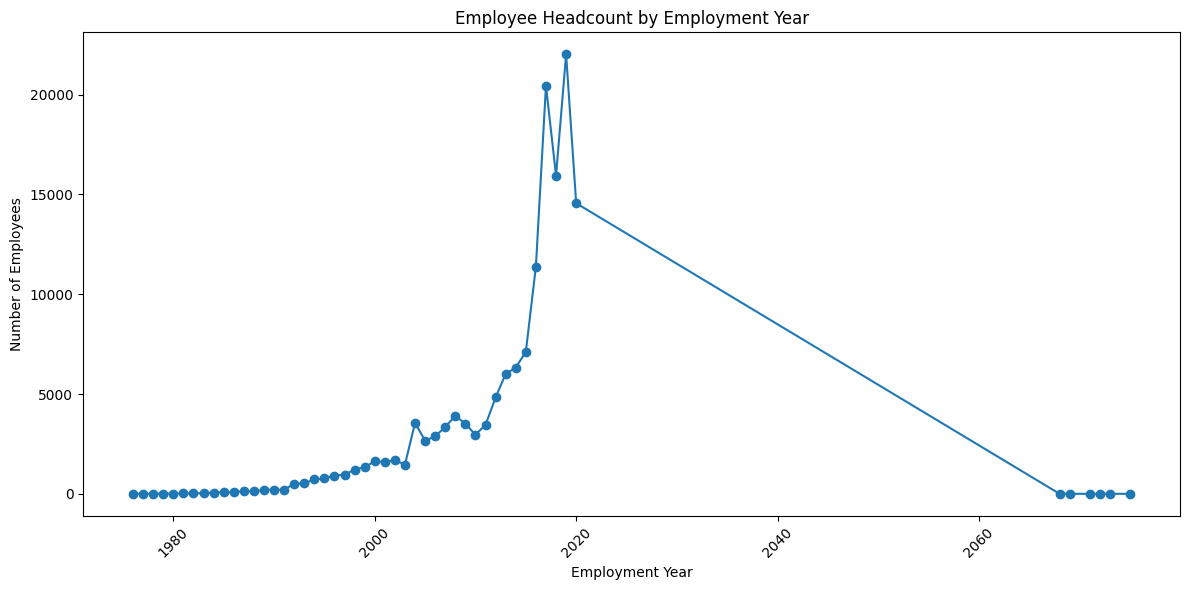

In [39]:
# 4. Plot headcount over time

plt.figure(figsize=(12,6), facecolor='white')
plt.plot(
    yearly_analysis['EMPLOY YEAR'],
    yearly_analysis['HEADCOUNT'],
    marker='o'
)

plt.title('Employee Headcount by Employment Year')
plt.xlabel('Employment Year')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
# 5. Analyze departments over time

department_year = data.groupby(['EMPLOY YEAR', 'AGENCY NAME']).agg(
    HEADCOUNT=('ANNUAL', 'count'),
    AVG_SALARY=('ANNUAL', 'mean'),
    MEDIAN_SALARY=('ANNUAL', 'median'),
    TOTAL_PAYROLL=('ANNUAL', 'sum')
).reset_index()

department_year

,EMPLOY YEAR,AGENCY NAME,HEADCOUNT,AVG_SALARY,MEDIAN_SALARY,TOTAL_PAYROLL
0,1976,COMPTROLLER OF PUBLIC ACCOUNTS ...,3,75437.72,74748.00,226313.16
1,1976,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",1,114549.84,114549.84,114549.84
2,1976,TEXAS LEGISLATIVE COUNCIL ...,1,95000.04,95000.04,95000.04
3,1977,COMPTROLLER OF PUBLIC ACCOUNTS ...,1,65709.00,65709.00,65709.00
4,1977,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",2,114549.84,114549.84,229099.68
...,...,...,...,...,...,...
2361,2071,DEPARTMENT OF PUBLIC SAFETY ...,1,86494.92,86494.92,86494.92
2362,2072,TEXAS DEPARTMENT OF TRANSPORTATION ...,1,40661.28,40661.28,40661.28
2363,2073,HOUSE OF REPRESENTATIVES ...,1,7200.00,7200.00,7200.00
2364,2073,TEXAS DEPARTMENT OF TRANSPORTATION ...,1,68796.00,68796.00,68796.00


In [41]:
# agency = 'HEALTH AND HUMAN SERVICES COMMISSION'
# department_year[department_year['AGENCY NAME'] == agency].sort_values('EMPLOY YEAR')

agency = 'HEALTH AND HUMAN SERVICES COMMISSION'

department_year[department_year['AGENCY NAME'] == agency].sort_values('EMPLOY YEAR')

,EMPLOY YEAR,AGENCY NAME,HEADCOUNT,AVG_SALARY,MEDIAN_SALARY,TOTAL_PAYROLL


In [42]:
# 6. Analyze roles over time

role_year = data.groupby(['EMPLOY YEAR', 'CLASS TITLE']).agg(
    HEADCOUNT=('ANNUAL', 'count'),
    AVG_SALARY=('ANNUAL', 'mean'),
    MEDIAN_SALARY=('ANNUAL', 'median'),
    TOTAL_PAYROLL=('ANNUAL', 'sum')
).reset_index()

In [43]:
top_roles = (
    data['CLASS TITLE'].value_counts().head(10).index
)
top_role_year = role_year[role_year['CLASS TITLE'].isin(top_roles)]

In [44]:
top_role_year.sort_values(['CLASS TITLE', 'EMPLOY YEAR'])

,EMPLOY YEAR,CLASS TITLE,HEADCOUNT,AVG_SALARY,MEDIAN_SALARY,TOTAL_PAYROLL
16,1979,ADMINISTRATIVE ASST III ...,1,37476.000000,37476.00,37476.00
78,1983,ADMINISTRATIVE ASST III ...,2,38858.940000,38858.94,77717.88
145,1985,ADMINISTRATIVE ASST III ...,1,46387.920000,46387.92,46387.92
206,1986,ADMINISTRATIVE ASST III ...,1,37901.520000,37901.52,37901.52
260,1987,ADMINISTRATIVE ASST III ...,2,39036.120000,39036.12,78072.24
...,...,...,...,...,...,...
10966,2016,TROOPER ...,420,57057.366286,53241.96,23964093.84
11735,2017,TROOPER ...,314,56306.077070,53241.96,17680108.20
12530,2018,TROOPER ...,164,54808.381463,53241.96,8988574.56
13378,2019,TROOPER ...,16,59810.250000,64918.92,956964.00


In [45]:
data['EMPLOY DECADE'] = (data['EMPLOY YEAR']//10)*10

In [46]:
decade_analysis = data.groupby('EMPLOY DECADE').agg(
    HEADCOUNT=('ANNUAL', 'count'),
    AVG_SALARY=('ANNUAL', 'mean'),
    MEDIAN_SALARY=('ANNUAL', 'median'),
    TOTAL_PAYROLL=('ANNUAL', 'sum')
).reset_index()

In [47]:
decade_analysis

,EMPLOY DECADE,HEADCOUNT,AVG_SALARY,MEDIAN_SALARY,TOTAL_PAYROLL
0,1970,29,92377.348966,90300.36,2.678943e+06
1,1980,781,87600.243995,80820.00,6.841579e+07
2,1990,7381,68428.245408,60274.44,5.050689e+08
3,2000,26244,58695.218116,50426.28,1.540397e+09
4,2010,100481,48470.796147,43049.04,4.870394e+09
5,2020,14557,40763.260133,36238.08,5.933908e+08
6,2060,3,49168.600000,48404.88,1.475058e+05
7,2070,5,63540.408000,68796.00,3.177020e+05


# Preprocessing

In [48]:
data.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search', 'ROLES', 'EMPLOY YEAR',
       'EMPLOY DECADE'],
      dtype='object')

In [49]:
data.isnull().sum()

,0
AGENCY,0
AGENCY NAME,0
LAST NAME,0
FIRST NAME,0
MI,0
CLASS CODE,0
CLASS TITLE,0
ETHNICITY,0
GENDER,0
STATUS,0


- duplicated, multiple_full_time_jobs, combined_multiple_jobs, summed_annual_salary, hide_from_search Columns has contain more than 90% Null values. so These columns will be deleted.
- ROLES, EMPLOY YEARS and EMPLOY DECADE columns not required. so thsese col also deleted
- AGENCY,LAST NAME, FIRST NAME, CLASS CODE, CLASS TITLE, STATE NUMBER columns are deleted because of high unique values

In [50]:
data.drop(['duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs', 'summed_annual_salary', 'hide_from_search'], axis=1, inplace=True)

In [51]:
data.drop(['ROLES','EMPLOY YEAR','EMPLOY DECADE'], axis=1, inplace=True)

In [52]:
data.drop(['AGENCY', 'LAST NAME', 'FIRST NAME', 'STATE NUMBER'], axis=1, inplace=True)

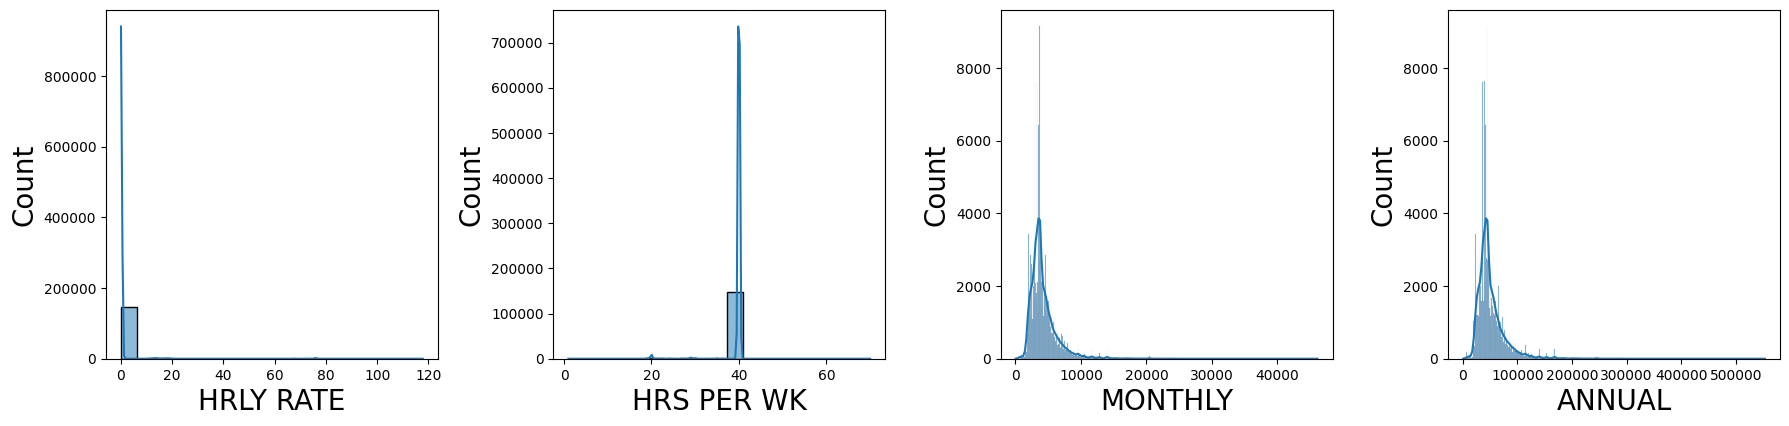

In [53]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(18, 8), facecolor='white')
plotnumber = 1
for i in numeric_data.columns:
  ax = plt.subplot(2,4, plotnumber)
  sns.histplot(data[i], kde=True)
  plt.xlabel(i, fontsize=20)
  plt.ylabel('Count', fontsize=20)
  plotnumber += 1
plt.tight_layout()
plt.show()

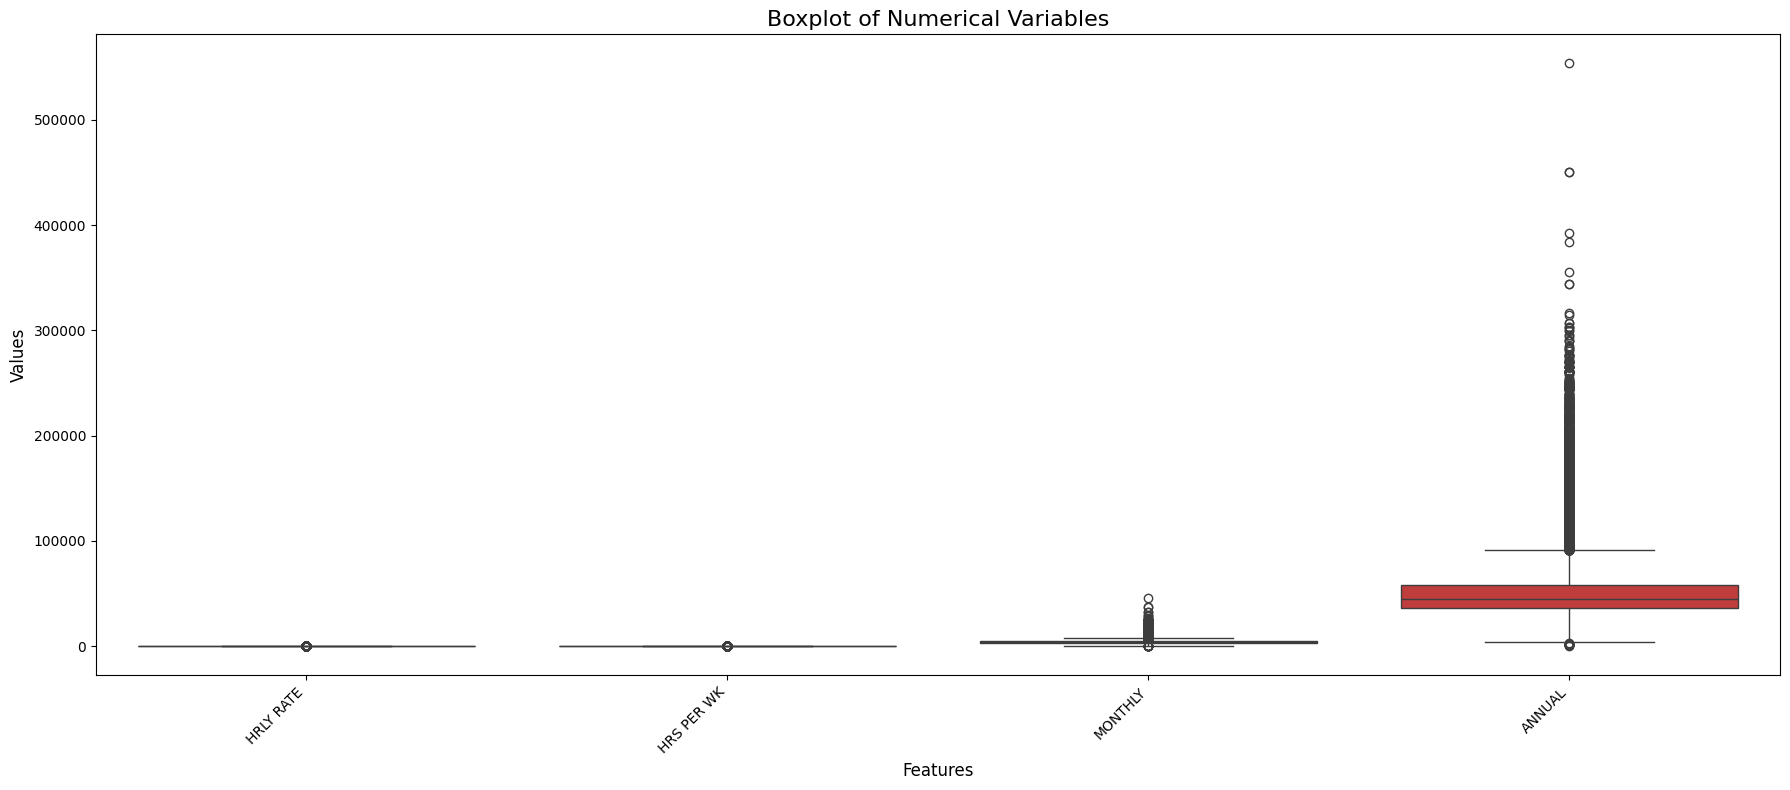

In [54]:
plt.figure(figsize=(18, 8))
sns.boxplot(data[numeric_data.columns])

plt.xticks(rotation=45,ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title('Boxplot of Numerical Variables', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Values', fontsize=12)

plt.tight_layout()
plt.show()

# Checking Co-relation of continuous data

In [55]:
data.head()

,AGENCY NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,1988-02-18,75.96150,29.0,9545.82,114549.84
1,OFFICE OF COURT ADMINISTRATION ...,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2015-02-01,81.04454,4.0,1404.77,16857.24
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,2020-02-01,75.96150,29.0,9545.82,114549.84
3,OFFICE OF COURT ADMINISTRATION ...,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2018-09-01,81.04453,4.0,1404.77,16857.24
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2020-06-29,0.00000,40.0,3284.27,39411.24


In [56]:
data.columns

Index(['AGENCY NAME', 'MI', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY', 'GENDER',
       'STATUS', 'EMPLOY DATE', 'HRLY RATE', 'HRS PER WK', 'MONTHLY',
       'ANNUAL'],
      dtype='object')

<Axes: >

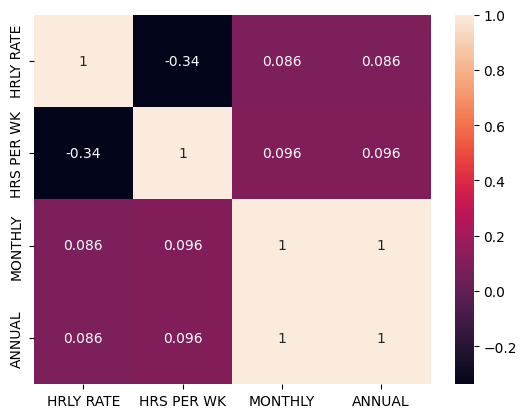

In [57]:
numeric_data_f = data.select_dtypes(include=['int64', 'float64'])

sns.heatmap(data[numeric_data_f.columns].corr(), annot=True)

In [58]:
data[numeric_data_f.columns].corr()

,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL
HRLY RATE,1.000000,-0.337784,0.086291,0.086291
HRS PER WK,-0.337784,1.000000,0.096041,0.096041
MONTHLY,0.086291,0.096041,1.000000,1.000000
ANNUAL,0.086291,0.096041,1.000000,1.000000


# Correlation Insights
- MONTHLY and ANNUAL show a perfect correlation (1.00) because annual salary is derived from monthly salary.

- summed_annual_salary has a very strong positive correlation with both MONTHLY and ANNUAL (~0.978).

- HRS PER WK has a moderate positive relationship with summed_annual_salary (0.529).

- AGENCY and STATE NUMBER show negative correlations with salary-related variables, but these are identifiers and should not be interpreted as meaningful continuous relationships.

- Salary-derived variables should be carefully handled during feature selection to avoid data leakage and multicollinearity

- Dropped MONTHLY column because Monthly and annual columns corelation is 1. and it is derrivatives of annual salary. and already Annual is considered as target variable.
- Monthly column Is highly corelated with annual. because annual is derrived from monthly. so dropped monthly column

In [59]:
data.drop(['MONTHLY'], axis=1, inplace=True)

In [60]:
data.columns

Index(['AGENCY NAME', 'MI', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY', 'GENDER',
       'STATUS', 'EMPLOY DATE', 'HRLY RATE', 'HRS PER WK', 'ANNUAL'],
      dtype='object')

Encoding on categorical column

In [61]:
data['MI'].value_counts()

,count
MI,
,38408
A,13520
L,13081
M,11973
D,9109
R,8344
J,7673
E,6158
C,5561


In [62]:
data['ETHNICITY'].value_counts()

,count
ETHNICITY,
WHITE,67142
HISPANIC,40585
BLACK,35853
ASIAN,4268
OTHER,921
AM INDIAN,712


In [63]:
data['GENDER'].value_counts()

,count
GENDER,
FEMALE,85328
MALE,64153


In [64]:
data['STATUS'].value_counts()

,count
STATUS,
CRF - CLASSIFIED REGULAR FULL-TIME,142502
URF - UNCLASSIFIED REGULAR FULL-TIME,2363
CRP - CLASSIFIED REGULAR PART-TIME,1531
CTF - CLASSIFIED TEMPORARY FULL-TIME,1096
URP - UNCLASSIFIED REGULAR PART-TIME,950
ERF - EXEMPT REGULAR FULL-TIME,923
CTP - CLASSIFIED TEMPORARY PART-TIME,81
UTP - UNCLASSIFIED TEMPORARY PART-TIME,21
UTF - UNCLASSIFIED TEMPORARY FULL-TIME,12


In [65]:
# data['CLASS TITLE'].value_counts()

In [66]:
# data['CLASS CODE'].value_counts()

In [67]:
data.dtypes

,0
AGENCY NAME,object
MI,object
CLASS CODE,object
CLASS TITLE,object
ETHNICITY,object
GENDER,object
STATUS,object
EMPLOY DATE,datetime64[ns]
HRLY RATE,float64
HRS PER WK,float64



we will devide EMPLOY DATE column by 12 and pass years other than that any type of scaling or no processing

In [68]:
data['EMPLOY DATE'] = pd.to_datetime(
    data['EMPLOY DATE'],
    errors='coerce'
)



In [69]:
data['EMPLOY YEAR'] = data['EMPLOY DATE'].dt.year

data.drop('EMPLOY DATE', axis=1, inplace=True)

### Employment Date Transformation

- Convert EMPLOY DATE into datetime format.
- Extract the employment year as EMPLOY YEAR.
- Drop the original EMPLOY DATE column.
- EMPLOY YEAR will be treated as a numerical feature and standardized.

In [70]:
data.head()

,AGENCY NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,HRLY RATE,HRS PER WK,ANNUAL,EMPLOY YEAR
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,1988
1,OFFICE OF COURT ADMINISTRATION ...,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04454,4.0,16857.24,2015
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,2020
3,OFFICE OF COURT ADMINISTRATION ...,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04453,4.0,16857.24,2018
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,39411.24,2020


In [71]:
data.isnull().sum()

,0
AGENCY NAME,0
MI,0
CLASS CODE,0
CLASS TITLE,0
ETHNICITY,0
GENDER,0
STATUS,0
HRLY RATE,0
HRS PER WK,0
ANNUAL,0


In [72]:
data.columns

Index(['AGENCY NAME', 'MI', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY', 'GENDER',
       'STATUS', 'HRLY RATE', 'HRS PER WK', 'ANNUAL', 'EMPLOY YEAR'],
      dtype='object')

In [73]:
#We need to impute Null values in the dataframe we will use simple imputers and we will have two categories here one with discrete null values and one with continuous null values
OHE_Columns = ['AGENCY NAME', 'MI', 'ETHNICITY', 'GENDER', 'STATUS','CLASS CODE', 'CLASS TITLE']

standard_scalar = ['HRLY RATE', 'HRS PER WK', 'EMPLOY YEAR']

# function_transformer = ['EMPLOY DATE']

# drop_cols = ['AGENCY','LAST NAME','FIRST NAME','STATE NUMBER','MONTHLY','duplicated','multiple_full_time_jobs','combined_multiple_jobs','summed_annual_salary',
#              'hide_from_search']

In [74]:
# data = pd.get_dummies(data, columns=OHE_Columns, drop_first=True, prefix = OHE_Columns)


In [75]:

data.head()

,AGENCY NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,HRLY RATE,HRS PER WK,ANNUAL,EMPLOY YEAR
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,1988
1,OFFICE OF COURT ADMINISTRATION ...,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04454,4.0,16857.24,2015
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,2020
3,OFFICE OF COURT ADMINISTRATION ...,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04453,4.0,16857.24,2018
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,39411.24,2020


In [76]:
# data['EMPLOY DATE'] = pd.to_datetime(data['EMPLOY DATE'], errors='coerce')

# data['EMPLOY DATE'] = data['EMPLOY DATE'].dt.year

In [77]:
data.head()

,AGENCY NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,HRLY RATE,HRS PER WK,ANNUAL,EMPLOY YEAR
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,1988
1,OFFICE OF COURT ADMINISTRATION ...,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04454,4.0,16857.24,2015
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,2020
3,OFFICE OF COURT ADMINISTRATION ...,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04453,4.0,16857.24,2018
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,39411.24,2020


In [78]:
# class ModifiedLabelEncoder(LabelEncoder):
#   def fit_transform(self, y, *args, **kwargs):
#     return super().fit_transform(y).reshape(-1,1)

#   def transform(self, y, *args, **kwargs):
#     return super().transform(y).reshape(-1,1)

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
preprocessor = ColumnTransformer([("OHE_Columns", OneHotEncoder(drop='first',handle_unknown='ignore'), OHE_Columns),
                                  ("Standard_Scalar", StandardScaler(), standard_scalar),

                                  ])

In [80]:
preprocessor

ColumnTransformer(transformers=[('OHE_Columns',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['AGENCY NAME', 'MI', 'ETHNICITY', 'GENDER',
                                  'STATUS', 'CLASS CODE', 'CLASS TITLE']),
                                ('Standard_Scalar', StandardScaler(),
                                 ['HRLY RATE', 'HRS PER WK', 'EMPLOY YEAR'])])

In [81]:
X = data.drop('ANNUAL', axis=1)
y = data['ANNUAL']

In [82]:
X.shape

(149481, 10)

In [83]:
X.head()

,AGENCY NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,HRLY RATE,HRS PER WK,EMPLOY YEAR
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,1988
1,OFFICE OF COURT ADMINISTRATION ...,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04454,4.0,2015
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,2020
3,OFFICE OF COURT ADMINISTRATION ...,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04453,4.0,2018
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,2020


In [84]:
y

,ANNUAL
0,114549.84
1,16857.24
2,114549.84
3,16857.24
4,39411.24
...,...
149476,34788.00
149477,66000.00
149478,13447.20
149479,68929.92


In [85]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
X_train.head()

,AGENCY NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,HRLY RATE,HRS PER WK,EMPLOY YEAR
59927,HEALTH AND HUMAN SERVICES COMMISSION ...,M,4422,LICENSED VOCATIONAL NURSE II ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2017
131365,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,A,4503,CORREC OFFCR III ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2019
4689,OFFICE OF THE ATTORNEY GENERAL ...,L,1582,PROGRAM SUPERVISOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2001
138760,PARKS AND WILDLIFE DEPARTMENT ...,W,2689,FISH AND WILDLIFE TECH II ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2008
66552,HEALTH AND HUMAN SERVICES COMMISSION ...,,5051,REHAB THERAPY TECHNICIAN II ...,BLACK,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2017


In [87]:
y_train

,ANNUAL
59927,37244.04
131365,36238.08
4689,64512.00
138760,42575.76
66552,26149.80
...,...
119879,45070.44
103694,43553.40
131932,41769.24
146867,42702.00


In [88]:
X_test.head()

,AGENCY NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,HRLY RATE,HRS PER WK,EMPLOY YEAR
133445,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,E,0055,CLERK I ...,HISPANIC,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2019
23389,DEPARTMENT OF PUBLIC SAFETY ...,L,0171,LICENSE AND PERMIT SPEC II ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2020
85047,TEXAS DEPARTMENT OF TRANSPORTATION ...,R,1603,MGR IV ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2015
27688,DEPARTMENT OF LICENSING AND REGULATION ...,A,3574,LEGAL ASSISTANT II ...,BLACK,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2011
99000,TEXAS JUVENILE JUSTICE DEPARTMENT ...,M,1603,MGR IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.0,40.0,2013


In [89]:
for col in OHE_Columns:
    # Convert column to string type to handle any mixed types, including numerical data that might have been
    # interpreted as int/float and actual string values.
    # Also, np.nan values will become the string 'nan' after astype(str).
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    # Replace the string 'nan' (from original NaN values) with 'Missing' or another appropriate placeholder.
    X_train[col].replace('nan', 'Missing', inplace=True)
    X_test[col].replace('nan', 'Missing', inplace=True)

In [90]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [92]:
lr = LinearRegression()
lr.fit(X_train_preprocessed, y_train)


LinearRegression()

In [93]:
y_pred = lr.predict(X_test_preprocessed )

In [94]:
print("R2 Score: ", r2_score(y_test, y_pred))

R2 Score:  0.9265446035455434


In [95]:
print("MAE: ", mean_absolute_error(y_test, y_pred))

MAE:  3331.787183594019


In [96]:
print("MSE: ", mean_squared_error(y_test, y_pred))

MSE:  47180529.8067978


In [97]:
print("RMSE: ", root_mean_squared_error(y_test, y_pred))

RMSE:  6868.808470673629


# Go with Decision Tree, Random gorest, XGB, GB  to improve r2 score

In [98]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dtr = dt.fit(X_train_preprocessed, y_train)

In [99]:
y_preddt = dt.predict(X_test_preprocessed)


In [100]:
print("R2 Score: ", r2_score(y_test, y_preddt))

R2 Score:  0.845653654376655


### Hyperparameters of DecisionTree

In [101]:
from sklearn.model_selection import GridSearchCV

In [102]:
# params = {
#     "criterion" : ["squared_error", "friedman_mse", "absolute_error", "poisson"],
#     "splitter" : ["best", "random"],
#     "max_depth" : list(range(1,10)),
#     "min_samples_split": [2, 3, 4, 5,6,7,8,9],
#     "min_samples_leaf": list(range(1, 10))
# }

params = {
    "criterion": ["squared_error", "friedman_mse"],
    # "splitter": ["best"],
    "splitter" : ["random"],
    "max_depth": [10,15,30, None],
    # "max_depth": [10, 15, 20, 25, 30, None],
    "min_samples_split": [5,20],
    "min_samples_leaf": [1, 2, 5,9]
}

tree_reg = DecisionTreeRegressor(random_state=42)
tree_cv = GridSearchCV(
    estimator = tree_reg,
    param_grid = params,
    scoring = "r2",
    n_jobs = -1,
    verbose=2,
    cv=5
)

tree_cv.fit(X_train_preprocessed, y_train)
best_params = tree_cv.best_params_
print(best_params)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
{'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 20, 'splitter': 'random'}


In [103]:
dt1 = DecisionTreeRegressor(criterion = 'squared_error', max_depth = None, min_samples_leaf = 1, min_samples_split = 20, splitter = 'random')

In [104]:
print("Best Parameters:", tree_cv.best_params_)
print("Best CV R2:", tree_cv.best_score_)

Best Parameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 20, 'splitter': 'random'}
Best CV R2: 0.8708024976666158


In [105]:
dt1.fit(X_train_preprocessed, y_train)

DecisionTreeRegressor(min_samples_split=20, splitter='random')

In [106]:
pred1 = dt1.predict(X_test_preprocessed)

In [107]:
print("R2 Score: ", r2_score(y_test, pred1))

R2 Score:  0.8766618230604298


After Hypertuning using GridsearchCV getting r2_score as 84.7%, so Better to use with Decision tree as its r2_score is 92%

In [ ]:
from sklearn.ensemble import RandomForestRegressor   # importing randomforest

rf_clf = RandomForestRegressor() # Assigning RandomForest Regressor into variable
rf_clf.fit(X_train_preprocessed,y_train)   # training the data




